In [ ]:
import os,sys;from pathlib import Path;sys.path.insert(0, str(Path(os.getcwd()).parent/'Notebooks'))
from imports import *


---

## Action item #1: Adding more ENAM stations

---


#### Current ENAM stations:

In [2]:
display(catalog[catalog.Experiment=='ENAM'])

,StaName,Station,Network,Latitude,Longitude,Experiment,Environment,Pressure_Gauge,StaDepth,Start,End,Events,Good_Channels,Deployment,Inventory
StaName,,,,,,,,,,,,,,,
YO.A06B,YO.A06B,A06B,YO,35.804501,-74.648804,ENAM,North Atlantic,DPG,1325.0,2014-04-03 00:00:00,2015-03-30 23:59:59,"[[resource_id, event_type, event_type_certaint...",True,"[StaName, Start, End, Water_Depth_m, Pressure_...","(((Channel 'HZ', Location '' \n\tTime range: -..."
YO.A01,YO.A01,A01,YO,33.9366,-75.726601,ENAM,North Atlantic,DPG,1755.0,2014-04-11 00:00:00,2015-04-03 23:59:59,"[[resource_id, event_type, event_type_certaint...",True,"[Station, Latitude, Longitude, Experiment, Ins...","(((Channel 'HZ', Location '' \n\tTime range: -..."
YO.X10,YO.X10,X10,YO,33.047501,-76.059898,ENAM,North Atlantic,DPG,2243.0,2014-04-11 00:00:00,2015-04-03 23:59:59,"[[resource_id, event_type, event_type_certaint...",True,"[Station, Latitude, Longitude, Experiment, Ins...","(((Channel 'HZ', Location '' \n\tTime range: -..."
YO.A04,YO.A04,A04,YO,35.034901,-75.000397,ENAM,North Atlantic,DPG,2293.0,2014-04-06 00:00:00,2015-04-01 23:59:59,"[[resource_id, event_type, event_type_certaint...",True,"[Station, Latitude, Longitude, Experiment, Ins...","(((Channel 'HZ', Location '' \n\tTime range: -..."
YO.X02,YO.X02,X02,YO,36.452599,-74.079002,ENAM,North Atlantic,DPG,2548.0,2014-04-02 00:00:00,2015-03-30 23:59:59,"[[resource_id, event_type, event_type_certaint...",True,"[Station, Latitude, Longitude, Experiment, Ins...","(((Channel 'HZ', Location '' \n\tTime range: -..."
YO.B02B,YO.B02B,B02B,YO,34.134701,-75.015701,ENAM,North Atlantic,DPG,3338.0,2014-04-09 00:00:00,2015-04-05 23:59:59,"[[resource_id, event_type, event_type_certaint...",True,"[Station, Latitude, Longitude, Experiment, Ins...","(((Channel 'HZ', Location '' \n\tTime range: -..."
YO.D06,YO.D06,D06,YO,35.392601,-73.765701,ENAM,North Atlantic,DPG,3352.0,2014-04-03 00:00:00,2015-03-30 23:59:59,"[[resource_id, event_type, event_type_certaint...",True,"[Station, Latitude, Longitude, Experiment, Ins...","(((Channel 'HZ', Location '' \n\tTime range: -..."
YO.X07,YO.X07,X07,YO,33.8036,-73.670502,ENAM,North Atlantic,DPG,4476.0,2014-04-07 00:00:00,2015-04-05 23:59:59,"[[resource_id, event_type, event_type_certaint...",True,"[Station, Latitude, Longitude, Experiment, Ins...","(((Channel 'HZ', Location '' \n\tTime range: -..."
YO.X09,YO.X09,X09,YO,32.516899,-74.3536,ENAM,North Atlantic,DPG,4726.0,2014-04-10 00:00:00,2015-04-03 23:59:59,"[[resource_id, event_type, event_type_certaint...",True,"[StaName, Start, End, Water_Depth_m, Pressure_...","(((Channel 'HZ', Location '' \n\tTime range: -..."


IRIS shows the ENAM network (YO) contains 128 stations that range from 26m to 5.2km

https://ds.iris.edu/mda/YO/?starttime=2014-01-01T00%3A00%3A00&endtime=2015-12-31T23%3A59%3A59

Constraining to the 30 (23 w/ good channels) used in Janiszewski et al., 2023 stations range at depths from 1.3km to 5.2km with all the same:

-instrument (BG), 

-seismometer (3Ts), 

-gauge (DPG),

-and deployment times (all in April '14)

Note: My records show we removed X01 from the dataset back in September due to quality issues.

In [3]:
HJan23=pd.read_excel(dirs.Catalogs/'Janiszewski_etal_2023_StationList.xlsx')
ENAM=HJan23[HJan23.Experiment=='ENAM'].copy();ENAM=ENAM[ENAM.T[-4:].sum(axis=0)==4]
ENAM.sort_values(by='Water Depth (m)',inplace=True)
display(ENAM)

,Station,Latitude (deg),Longitude (deg),Experiment,Instrument Design,Seismometer,Pressure Gauge,Environment,Water Depth (m),Distance from Land (km),...,Network,Original Sample Rate Seismic (sps),Original Sample Rate Pressure (sps),Start,End,Deployment Length (days),Z Is Good,H1 Is Good,H2 Is Good,P Is Good
364,A06B,35.804501,-74.648804,ENAM,BG,Guralp CMG3T 120,DPG,North Atlantic,1325.0,81,...,YO,100.0,20.0,2014-04-03,2015-03-30 23:59:59,362,1,1,1,1
365,X01,36.225201,-74.579300,ENAM,BG,Guralp CMG3T 120,DPG,North Atlantic,1329.0,94,...,YO,100.0,20.0,2014-04-03,2015-03-30 23:59:59,362,1,1,1,1
366,A01,33.936600,-75.726601,ENAM,BG,Guralp CMG3T 120,DPG,North Atlantic,1755.0,116,...,YO,100.0,20.0,2014-04-11,2015-04-03 23:59:59,358,1,1,1,1
368,X10,33.047501,-76.059898,ENAM,BG,Guralp CMG3T 120,DPG,North Atlantic,2243.0,188,...,YO,100.0,20.0,2014-04-11,2015-04-03 23:59:59,358,1,1,1,1
369,A04,35.034901,-75.000397,ENAM,BG,Guralp CMG3T 120,DPG,North Atlantic,2293.0,91,...,YO,100.0,20.0,2014-04-06,2015-04-01 23:59:59,361,1,1,1,1
371,X02,36.452599,-74.079002,ENAM,BG,Guralp CMG3T 120,DPG,North Atlantic,2548.0,143,...,YO,100.0,20.0,2014-04-02,2015-03-30 23:59:59,363,1,1,1,1
372,A03,34.691101,-75.210899,ENAM,BG,Guralp CMG3T 120,DPG,North Atlantic,2638.0,101,...,YO,100.0,20.0,2014-04-08,2015-04-05 23:59:59,363,1,1,1,1
373,A02,34.357498,-75.448799,ENAM,BG,Guralp CMG3T 120,DPG,North Atlantic,2779.0,96,...,YO,100.0,20.0,2014-04-08,2015-04-05 23:59:59,363,1,1,1,1
375,B05B,35.175900,-74.345100,ENAM,BG,Guralp CMG3T 120,DPG,North Atlantic,2961.0,128,...,YO,100.0,20.0,2014-04-05,2015-03-31 23:59:59,361,1,1,1,1
376,C04,34.879799,-74.646500,ENAM,BG,Guralp CMG3T 120,DPG,North Atlantic,3023.0,127,...,YO,100.0,20.0,2014-04-06,2015-04-01 23:59:59,361,1,1,1,1


-With all the important metrics being equal across ENAM I can just select stations that continue to round out the same depth distribution a little bit more. 

-I'll bring the total to 11 so we have room to lose 1 during QC.

That in mind, this is the updated ENAM selection:

In [4]:
ENAM[ENAM.Station.isin(['A06B','X09','X06','A01','X10','A04','X02','B02B','D06','X08','X07'])]

,Station,Latitude (deg),Longitude (deg),Experiment,Instrument Design,Seismometer,Pressure Gauge,Environment,Water Depth (m),Distance from Land (km),...,Network,Original Sample Rate Seismic (sps),Original Sample Rate Pressure (sps),Start,End,Deployment Length (days),Z Is Good,H1 Is Good,H2 Is Good,P Is Good
364,A06B,35.804501,-74.648804,ENAM,BG,Guralp CMG3T 120,DPG,North Atlantic,1325.0,81,...,YO,100.0,20.0,2014-04-03,2015-03-30 23:59:59,362,1,1,1,1
366,A01,33.936600,-75.726601,ENAM,BG,Guralp CMG3T 120,DPG,North Atlantic,1755.0,116,...,YO,100.0,20.0,2014-04-11,2015-04-03 23:59:59,358,1,1,1,1
368,X10,33.047501,-76.059898,ENAM,BG,Guralp CMG3T 120,DPG,North Atlantic,2243.0,188,...,YO,100.0,20.0,2014-04-11,2015-04-03 23:59:59,358,1,1,1,1
369,A04,35.034901,-75.000397,ENAM,BG,Guralp CMG3T 120,DPG,North Atlantic,2293.0,91,...,YO,100.0,20.0,2014-04-06,2015-04-01 23:59:59,361,1,1,1,1
371,X02,36.452599,-74.079002,ENAM,BG,Guralp CMG3T 120,DPG,North Atlantic,2548.0,143,...,YO,100.0,20.0,2014-04-02,2015-03-30 23:59:59,363,1,1,1,1
380,B02B,34.134701,-75.015701,ENAM,BG,Guralp CMG3T 120,DPG,North Atlantic,3338.0,143,...,YO,100.0,20.0,2014-04-09,2015-04-05 23:59:59,362,1,1,1,1
381,D06,35.392601,-73.765701,ENAM,BG,Guralp CMG3T 120,DPG,North Atlantic,3352.0,167,...,YO,100.0,20.0,2014-04-03,2015-03-30 23:59:59,362,1,1,1,1
390,X07,33.803600,-73.670502,ENAM,BG,Guralp CMG3T 120,DPG,North Atlantic,4476.0,269,...,YO,100.0,20.0,2014-04-07,2015-04-05 23:59:59,364,1,1,1,1
391,X09,32.516899,-74.353600,ENAM,BG,Guralp CMG3T 120,DPG,North Atlantic,4726.0,318,...,YO,100.0,20.0,2014-04-10,2015-04-03 23:59:59,359,1,1,1,1
392,X06,33.650700,-72.205704,ENAM,BG,Guralp CMG3T 120,DPG,North Atlantic,5154.0,387,...,YO,100.0,20.0,2014-04-07,2015-04-02 23:59:59,361,1,1,1,1



---
# Action item #2: Add more events to fill in a low station-density gap from 6 to 10 stations/event range.
---

## As a segway into the next action items, getting more events for the low-mid station density events:




+ I guess by sheer coincidence of the ENAM deployment time and the events in my catalog...
    + we see (below) these new stations actually exascerbates the station-density disparity even more by adding to the higher station density event bins (and subtracting from the lower density ones).
    + I know this from assuming any event with an ENAM station in the current event catalog will now have these 8 additional ENAM stations (bottom subplot).
+ It's interesting nonetheless as this actually highlights the obvious solution to the event-density problem, add events around the deployment times that currently feed the 6-10 bins until each one is atleast 10+.

        >The additional events should only cove mags 6-6.5 to specifically target the gap also seen in histograms of event magnitude (too low in this range)

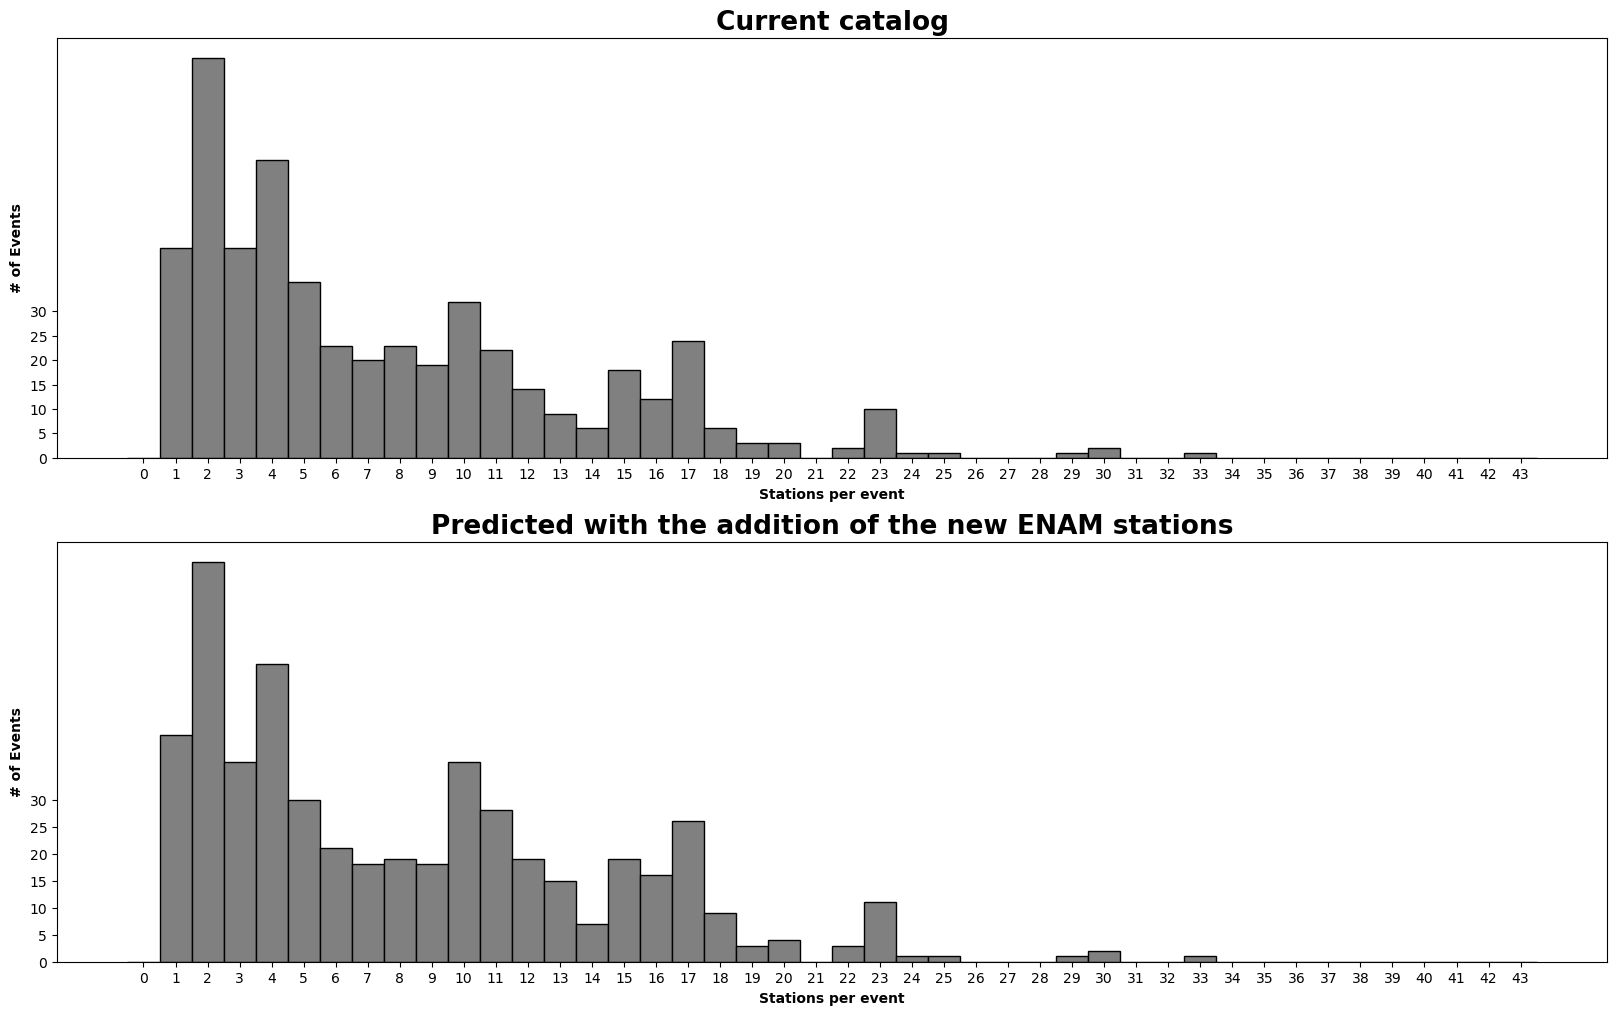

In [5]:
def moving_average(x, w):return np.convolve(x, np.ones(w), 'valid') / w
y=[int(i[1]) for i in np.unique(unravel([[[e.Name,len(e.Stations)] for e in s.Events] for s in catalog.iloc]),axis=0)]
fig,axes = plt.subplots(nrows=2,ncols=1,figsize=(20,12))
bins=[i for i in range(45)]
ax=axes[0]
a=ax.hist(y,bins=bins,edgecolor='k',color='gray')
out_bins = a[1]
centers = moving_average(out_bins,2)
centers = moving_average(bins,2)
_=ax.set_xticks(centers)
ax.set_xticklabels([int(c) for c in centers])
ax.set_xlabel('Stations per event',fontweight='bold')
ax.set_ylabel('# of Events',fontweight='bold')
ax.set_title('Current catalog',fontsize=19,fontweight='bold')
ax.set_yticks(np.arange(0,35,5))
currentenam = ['YO.X09','YO.A06B','YO.X06']
y=[int(i[1]) for i in np.unique(unravel([ [[e.Name,len(e.Stations)] if np.isin(e.Stations,currentenam).sum()==0 else [e.Name,len(e.Stations)+8] for e in s.Events] for s in catalog.iloc]),axis=0)]
ax=axes[1]
a=ax.hist(y,bins=bins,edgecolor='k',color='gray')
out_bins = a[1]
centers = moving_average(out_bins,2)
centers = moving_average(bins,2)
_=ax.set_xticks(centers)
ax.set_xticklabels([int(c) for c in centers])
ax.set_xlabel('Stations per event',fontweight='bold')
ax.set_ylabel('# of Events',fontweight='bold')
ax.set_title('Predicted with the addition of the new ENAM stations',fontsize=19,fontweight='bold')
_=ax.set_yticks(np.arange(0,35,5))

### Getting specific on the time ranges that will fill in the gaps, using the current catalog, we can look at station density as a function of time:

### Red are all the dates that added to the 6-10 range of bins in the density plot above. Sufficient additional events in the red areas will fill in the density gap.

+ It's important to acknowledge that these are not hard defined ranges as it only defines the areas that fill in the density gap that I've already collected data in. 
    + That said, I've already permuted through every setup to search for events that can cover the most stations possible so any additional event not shown in the plot below most likely not improve a station density coverage
    + Furthermore, in these same time ranges I've not only gotten the data that adds to the station density that we need but it's also ranges that have been QC'd and produced good events based on those I've collected.
    + All of this is to say while the red regions only represent a general layout of where to search for more events, going too far outside those areas may not necessarily help and sticking to them as much as reasonable can mitigate the amount of suprises that may pop up in QC.

## In total, this amounts to something on the order of 60-80 (20% increase) new events to fix the event-density problem.


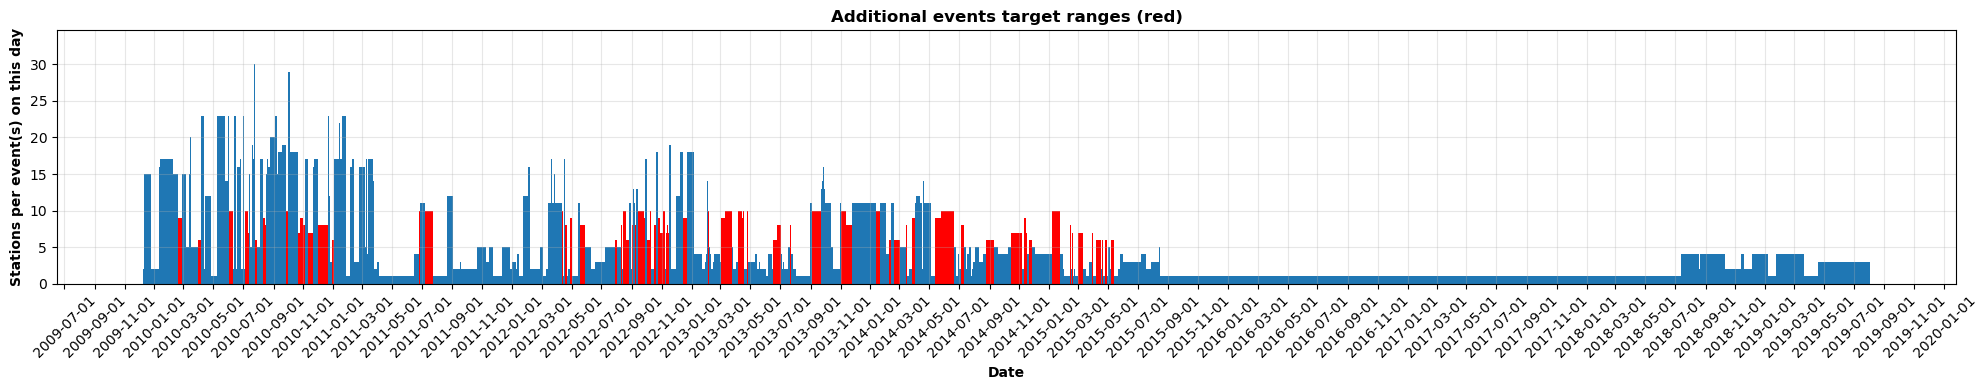

In [6]:
import matplotlib.dates as mdates
stadensity=np.unique(unravel([[[e.Name,len(e.Stations)] for e in s.Events] for s in catalog.iloc]),axis=0)
nsta=np.array([int(i[1]) for i in stadensity])
evna=np.array([i[0] for i in stadensity])
dateformat = '%Y.%j.%H.%M'
evcull=([UTCDateTime.strptime(i,dateformat) for i in np.sort(evna[(nsta>=6) & (nsta<=10)])])
plotdates=[UTCDateTime.strptime(i,dateformat) for i in evna]
allevents=np.array(unravel([np.repeat(UTCDateTime.strptime(i,dateformat),n) for i,n in zip(evna,nsta)]))
plotdates=allevents
bins=20
bins=allevents.shape[0]
bins=mdates.date2num(allevents)
plt.figure(figsize=(20,4))
plt.hist(mdates.date2num(allevents), bins=bins)
a= plt.hist(mdates.date2num([i for i in allevents if np.isin(i,evcull)]), bins=bins,facecolor='r')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator(minticks=50,maxticks=100,interval_multiples=False))
plt.grid(alpha=0.3)
plt.xticks(rotation=45);plt.xlabel('Date',fontweight='bold');plt.ylabel('Stations per event(s) on this day',fontweight='bold');plt.title('Additional events target ranges (red)',fontweight='bold')
plt.tight_layout();plt.show()

# Action item #3: The number of m6-6.5 events is far too low, add more. 

### Building on the above in terms of the magnitude gap in the m6-6.5 range (below). 
#### If these 60-80 additional events are focused only on that mag range, it will easily solve the mag disparity aswell.

Text(0, 0.5, 'Events')

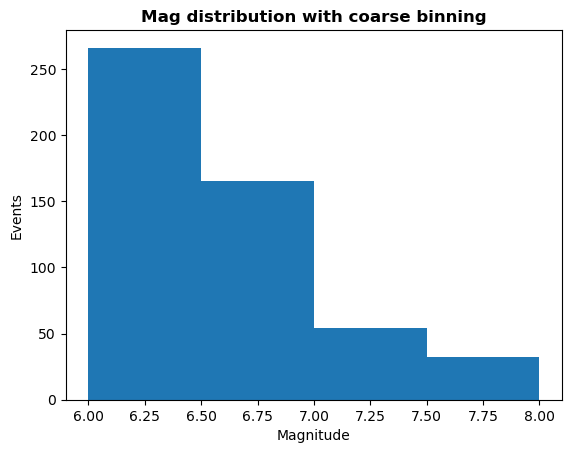

In [7]:
evm=Catalog(unravel([s.Events for s in catalog.iloc]))
evm=Catalog([evm[i] for i in np.unique([e.Name for e in evm],return_index=True)[1]])
evmags=np.array([e.magnitudes[0].mag for e in evm])
plt.hist(evmags,bins=[6,6.5,7.0,7.5,8.0])
plt.title('Mag distribution with coarse binning',fontweight='bold')
plt.xlabel('Magnitude')
plt.ylabel('Events')

### In practice, the additions to the dataset becomes very simple, and is just reduced to telling ATaCR to focus on events in these mag/date ranges below (based on above figures) and skip any event that is not shared by the desired number (6-10) of stations based on their deployment times. 

    Dataset addendum summary:
        [1] Add the following ENAM stations to the catalog:
            1.  YO.A01
            2.  YO.X10
            3.  YO.A04
            4.  YO.X02
            5.  YO.B02B
            6.  YO.D06
            7.  YO.X08
            8.  YO.X07
        [2] Collect 60-80 (+20%) events with the new event search criteria:
            M6-6.5
            2010/06 - 2010/11
            2012/08 - 2012/11
            2013/01 - 2013/07
            2014/06 - 2014/08
            2015/01 - 2015/05

    > I wrote this notebook up on 01/01/25 and event downloads are relatively quick (compared to noise, which the new ENAM also needs) so I will hopefully have this on disk and a tally of how it updates the histograms sometime tomorrow.

## This plan now laid out for an ~20% increase in the event catalog (m6-6.5) and 8 additional ENAM stations, its time to start the download followed up with QC of new data...

# [Update 01.03.25]:
## The new data is now downloaded that includes the additional ENAM stations and adjustments to the event catalog as detailed above.

## For reference, here is the histogram of interest before the changes to the dataset:

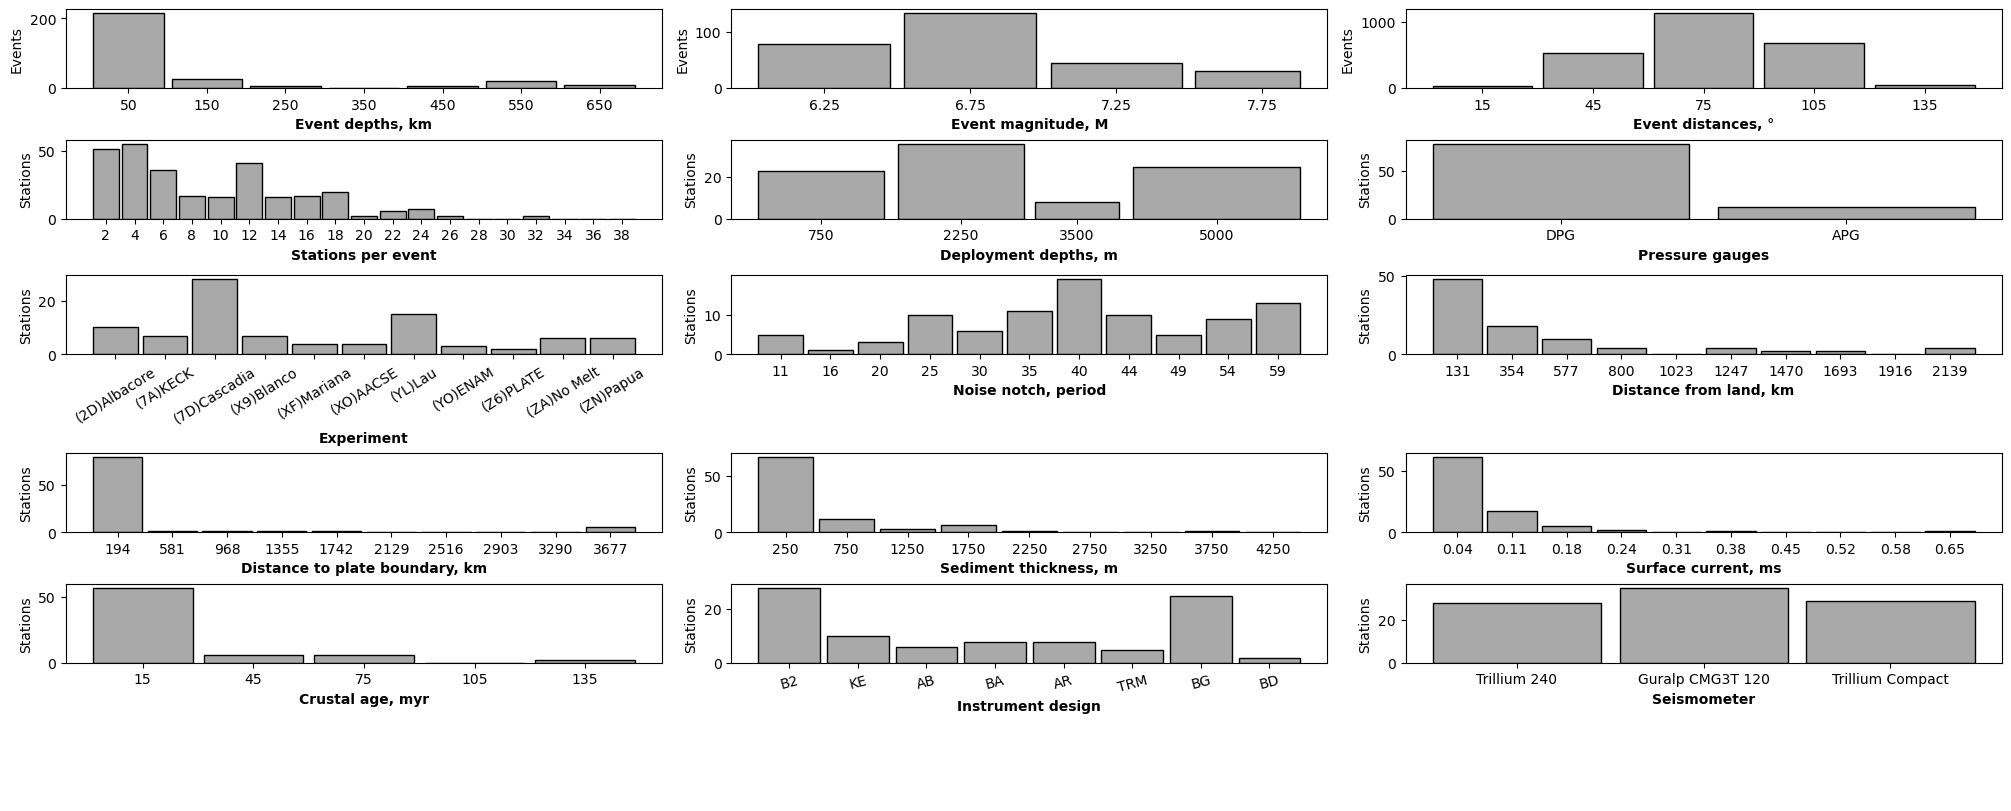

In [8]:
fig=meta_hist_plot(pd.read_pickle(dirs.Catalogs / 'sta_catalog_111524c.pkl'))
# ![meta_plot.png](./znb_images/meta_plot.png)

## And here is with the updated dataset:

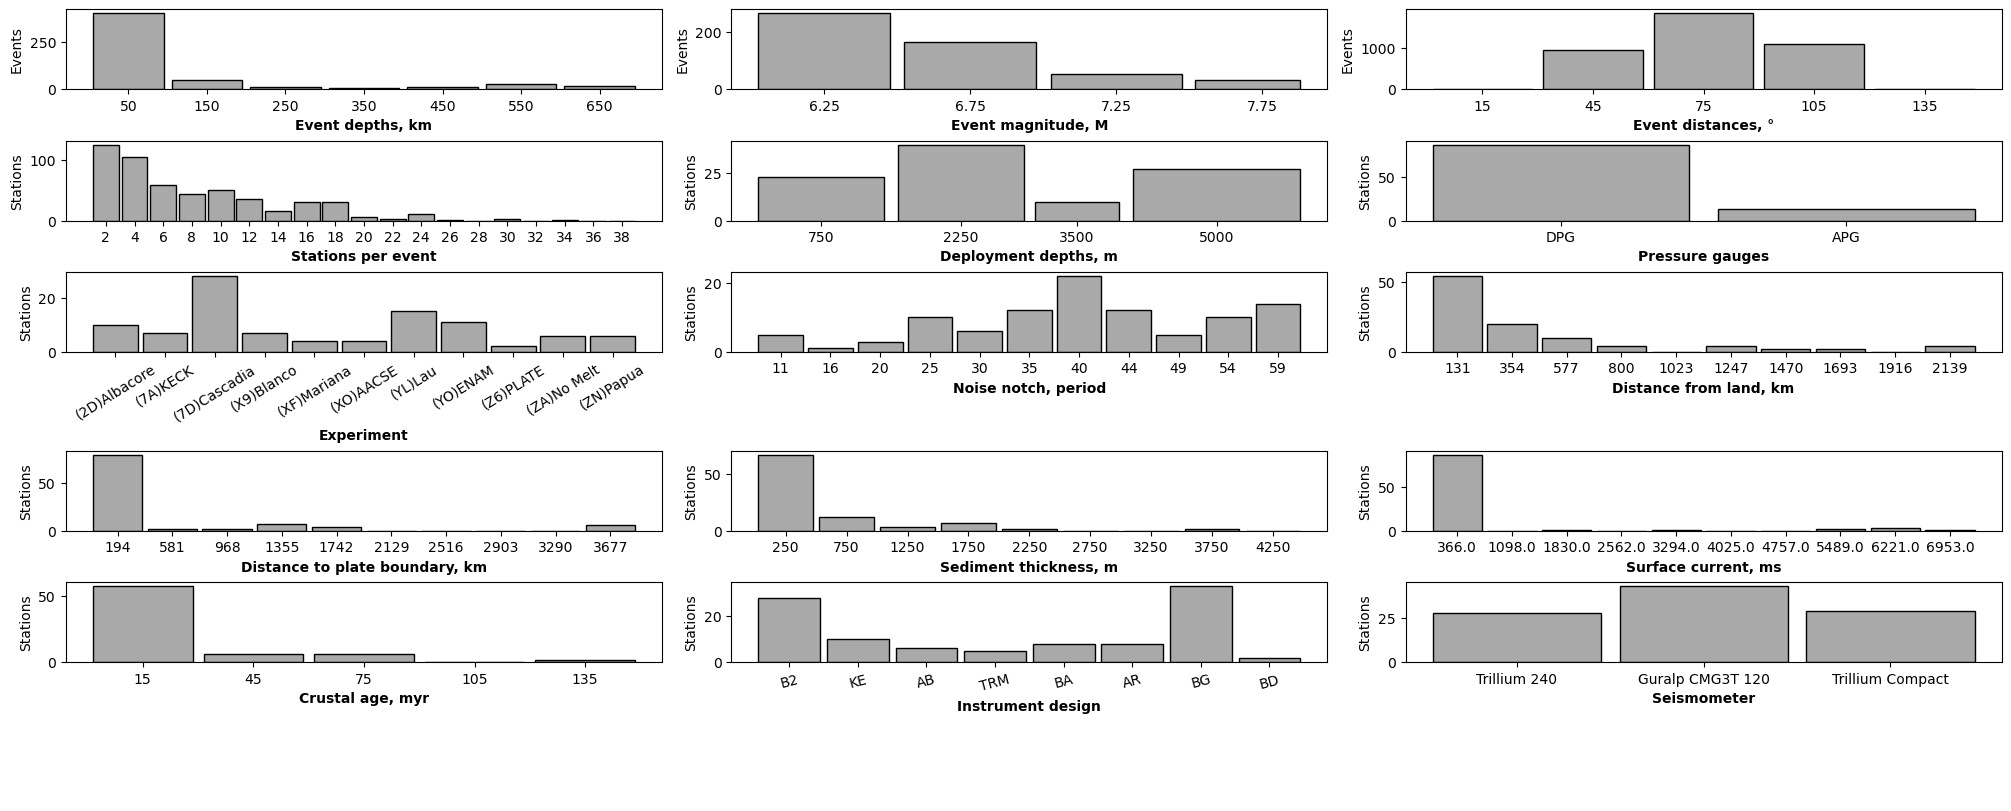

In [9]:
fig=meta_hist_plot(catalog)


___
## A few points:
### --Overall, the new additions is a total 40% increase in the event catalog. I had went a bit over what I had predicted for this so I could add a few more M7+ high station density events and make the GR mag-frequency power law a little more obvious in the dataset.

### --There is maybe 10 more events at most I still need to download to make sure the new ENAM stations each have a minimum of 20 events. A few of them still only have a dozen or so.

### --QC on the new events still needs to be done. Given that a large majority of the new events or sub M6.5, it's very possible a non-zero, if not non-trivial, amount will be taken away after QC.

___
## Next steps:

### --Download just a few more events for the new ENAM stations to bring each up to atleast 20 events.
### --Get the noise spectra for the new ENAM stations.
### --Download the NoiseCut (24hr traces) event twin for each of the new events. 
        This step will be quite data heavy but, luckily, there's no code that has to be written. It's just press play and wait.
### --Push through ATaCR and NoiseCut
### --QC all the new events.
### --Evaluate results/notes on QC.
___